In [1]:
import pandas as pd
import numpy as np
import random
from datetime import datetime, timedelta

np.random.seed(42)
random.seed(42)

# Aircraft types with realistic fuel burn rates (kg/hour)
aircraft_fuel_profiles = {
    'B737-800': {'base_burn': 2400, 'variance': 150},
    'A320': {'base_burn': 2300, 'variance': 140},
    'Q400': {'base_burn': 900, 'variance': 80},
    'CRJ900': {'base_burn': 1100, 'variance': 90},
}

routes = [
    ('Lagos', 'Abuja', 55),
    ('Lagos', 'Port Harcourt', 45),
    ('Abuja', 'Kano', 50),
    ('Lagos', 'Kano', 90),
    ('Abuja', 'Port Harcourt', 60),
    ('Lagos', 'Enugu', 50),
    ('Abuja', 'Enugu', 45),
]

airlines = ['Air Peace', 'Ibom Air', 'Dana Air', 
            'United Nigeria', 'Overland Airways']

aircraft_ids = ['5N-BWA', '5N-BWB', '5N-BWC', '5N-BWD', 
                '5N-BWE', '5N-BWF', '5N-BWG', '5N-BWH']

FUEL_PRICE_PER_KG = 1.35  # USD per kg (Jet A-1 approx)
NGN_RATE = 1650  # approximate NGN/USD

rows = []
start_date = datetime(2025, 1, 1)

for i in range(600):
    route = random.choice(routes)
    origin, dest, duration_mins = route
    airline = random.choice(airlines)
    aircraft_type = random.choice(list(aircraft_fuel_profiles.keys()))
    aircraft_id = random.choice(aircraft_ids)
    
    flight_date = start_date + timedelta(days=random.randint(0, 180))
    
    profile = aircraft_fuel_profiles[aircraft_type]
    duration_hours = duration_mins / 60
    
    # Planned fuel burn
    planned_burn = profile['base_burn'] * duration_hours
    
    # Actual fuel burn - introduce realistic inefficiencies
    inefficiency_factor = 1.0
    
    # Some flights have operational inefficiencies
    anomaly_roll = random.random()
    if anomaly_roll < 0.08:  # 8% severe anomaly
        inefficiency_factor = random.uniform(1.15, 1.35)
        anomaly_type = 'Severe'
    elif anomaly_roll < 0.20:  # 12% moderate
        inefficiency_factor = random.uniform(1.05, 1.15)
        anomaly_type = 'Moderate'
    else:
        inefficiency_factor = random.uniform(0.97, 1.05)
        anomaly_type = 'Normal'
    
    actual_burn = planned_burn * inefficiency_factor
    actual_burn += np.random.normal(0, profile['variance'] * 0.3)
    
    fuel_variance_kg = actual_burn - planned_burn
    fuel_variance_pct = (fuel_variance_kg / planned_burn) * 100
    
    cost_variance_usd = fuel_variance_kg * FUEL_PRICE_PER_KG
    cost_variance_ngn = cost_variance_usd * NGN_RATE
    
    # Determine likely cause of inefficiency
    if fuel_variance_pct > 15:
        cause = random.choice(['Excess Taxi Time', 'Non-Optimal Altitude', 
                                'Weather Diversion', 'ATC Holding Pattern'])
    elif fuel_variance_pct > 5:
        cause = random.choice(['Suboptimal Routing', 'Extra APU Usage',
                                'Ground Delay', 'Minor ATC Delay'])
    else:
        cause = 'Within Normal Range'
    
    rows.append({
        'Flight_ID': f'NG{2000+i}',
        'Flight_Date': flight_date.strftime('%Y-%m-%d'),
        'Airline': airline,
        'Aircraft_ID': aircraft_id,
        'Aircraft_Type': aircraft_type,
        'Route': f"{origin}-{dest}",
        'Flight_Duration_Mins': duration_mins,
        'Planned_Fuel_KG': round(planned_burn, 1),
        'Actual_Fuel_KG': round(actual_burn, 1),
        'Fuel_Variance_KG': round(fuel_variance_kg, 1),
        'Fuel_Variance_Pct': round(fuel_variance_pct, 2),
        'Cost_Variance_USD': round(cost_variance_usd, 2),
        'Cost_Variance_NGN': round(cost_variance_ngn, 2),
        'Anomaly_Level': anomaly_type,
        'Likely_Cause': cause
    })

df = pd.DataFrame(rows)
df.to_csv('fuel_efficiency_data.csv', index=False)

print("✅ Fuel dataset created successfully")
print(f"Total flights: {len(df)}")
print(f"\nAnomaly distribution:")
print(df['Anomaly_Level'].value_counts())
print(f"\nTotal excess cost (NGN): ₦{df[df['Cost_Variance_NGN']>0]['Cost_Variance_NGN'].sum():,.2f}")
print(f"Total excess cost (USD): ${df[df['Cost_Variance_USD']>0]['Cost_Variance_USD'].sum():,.2f}")
print(f"\nWorst aircraft by avg variance:")
print(df.groupby('Aircraft_ID')['Fuel_Variance_Pct'].mean().sort_values(ascending=False).round(2))

✅ Fuel dataset created successfully
Total flights: 600

Anomaly distribution:
Anomaly_Level
Normal      501
Moderate     62
Severe       37
Name: count, dtype: int64

Total excess cost (NGN): ₦98,938,657.93
Total excess cost (USD): $59,962.80

Worst aircraft by avg variance:
Aircraft_ID
5N-BWF    5.06
5N-BWG    4.33
5N-BWC    3.91
5N-BWA    3.72
5N-BWB    3.48
5N-BWD    3.26
5N-BWH    3.21
5N-BWE    2.32
Name: Fuel_Variance_Pct, dtype: float64


In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('fuel_efficiency_data.csv')

print("=" * 55)
print("FUEL EFFICIENCY INTELLIGENCE REPORT")
print("=" * 55)

# 1. Overall Financial Impact
print("\n💰 FINANCIAL IMPACT SUMMARY")
total_excess_ngn = df[df['Cost_Variance_NGN']>0]['Cost_Variance_NGN'].sum()
total_excess_usd = df[df['Cost_Variance_USD']>0]['Cost_Variance_USD'].sum()
avg_variance_pct = df['Fuel_Variance_Pct'].mean()

print(f"Total Flights Analyzed:      {len(df)}")
print(f"Total Excess Fuel Cost:      ₦{total_excess_ngn:,.2f}")
print(f"Total Excess Fuel Cost:      ${total_excess_usd:,.2f}")
print(f"Average Fuel Variance:       {avg_variance_pct:.2f}%")
print(f"Annualized Projection (NGN): ₦{total_excess_ngn * 2:,.2f}")  # 6mo → 12mo

# 2. By Aircraft
print("\n✈️ FUEL EFFICIENCY BY AIRCRAFT")
aircraft_stats = df.groupby('Aircraft_ID').agg(
    Avg_Variance_Pct=('Fuel_Variance_Pct', 'mean'),
    Total_Excess_NGN=('Cost_Variance_NGN', lambda x: x[x>0].sum()),
    Flight_Count=('Flight_ID', 'count')
).round(2).sort_values('Avg_Variance_Pct', ascending=False)
print(aircraft_stats)

# 3. By Airline
print("\n🏢 FUEL EFFICIENCY BY AIRLINE")
airline_stats = df.groupby('Airline').agg(
    Avg_Variance_Pct=('Fuel_Variance_Pct', 'mean'),
    Total_Excess_NGN=('Cost_Variance_NGN', lambda x: x[x>0].sum()),
    Flight_Count=('Flight_ID', 'count')
).round(2).sort_values('Avg_Variance_Pct', ascending=False)
print(airline_stats)

# 4. By Route
print("\n🛫 FUEL EFFICIENCY BY ROUTE")
route_stats = df.groupby('Route').agg(
    Avg_Variance_Pct=('Fuel_Variance_Pct', 'mean'),
    Total_Excess_NGN=('Cost_Variance_NGN', lambda x: x[x>0].sum()),
    Flight_Count=('Flight_ID', 'count')
).round(2).sort_values('Avg_Variance_Pct', ascending=False)
print(route_stats)

# 5. By Root Cause
print("\n⚠️ EXCESS FUEL BY LIKELY CAUSE")
cause_stats = df[df['Likely_Cause']!='Within Normal Range'].groupby('Likely_Cause').agg(
    Avg_Variance_Pct=('Fuel_Variance_Pct', 'mean'),
    Total_Excess_NGN=('Cost_Variance_NGN', lambda x: x[x>0].sum()),
    Frequency=('Flight_ID', 'count')
).round(2).sort_values('Total_Excess_NGN', ascending=False)
print(cause_stats)

# 6. Anomaly severity breakdown
print("\n🚨 ANOMALY SEVERITY BREAKDOWN")
severity_stats = df.groupby('Anomaly_Level').agg(
    Count=('Flight_ID', 'count'),
    Avg_Variance_Pct=('Fuel_Variance_Pct', 'mean'),
    Total_Excess_NGN=('Cost_Variance_NGN', lambda x: x[x>0].sum())
).round(2)
print(severity_stats)

# Save all stats for Power BI
with pd.ExcelWriter('fuel_analysis.xlsx', engine='openpyxl') as writer:
    aircraft_stats.to_excel(writer, sheet_name='Aircraft_Stats')
    airline_stats.to_excel(writer, sheet_name='Airline_Stats')
    route_stats.to_excel(writer, sheet_name='Route_Stats')
    cause_stats.to_excel(writer, sheet_name='Cause_Stats')
    severity_stats.to_excel(writer, sheet_name='Severity_Stats')
    df.to_excel(writer, sheet_name='Raw_Data')

print("\n✅ Analysis complete — fuel_analysis.xlsx saved")

FUEL EFFICIENCY INTELLIGENCE REPORT

💰 FINANCIAL IMPACT SUMMARY
Total Flights Analyzed:      600
Total Excess Fuel Cost:      ₦98,938,657.93
Total Excess Fuel Cost:      $59,962.80
Average Fuel Variance:       3.61%
Annualized Projection (NGN): ₦197,877,315.86

✈️ FUEL EFFICIENCY BY AIRCRAFT
             Avg_Variance_Pct  Total_Excess_NGN  Flight_Count
Aircraft_ID                                                  
5N-BWF                   5.06       13586156.49            61
5N-BWG                   4.33       14637797.39            78
5N-BWC                   3.91       15427748.08            85
5N-BWA                   3.72        9255015.47            61
5N-BWB                   3.48       15891998.39            92
5N-BWD                   3.26       10683197.42            69
5N-BWH                   3.21        9632155.02            69
5N-BWE                   2.32        9824589.67            85

🏢 FUEL EFFICIENCY BY AIRLINE
                  Avg_Variance_Pct  Total_Excess_NGN  Fli

C:\Users\User\AppData\Local\Temp\ipykernel_8368\3240136010.py:61: UserWarning: Glyph 9981 (\N{FUEL PUMP}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_8368\3240136010.py:62: UserWarning: Glyph 9981 (\N{FUEL PUMP}) missing from font(s) DejaVu Sans.
  plt.savefig('fuel_analysis_charts.png', dpi=150, bbox_inches='tight', facecolor='#0D1B2A')
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9981 (\N{FUEL PUMP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


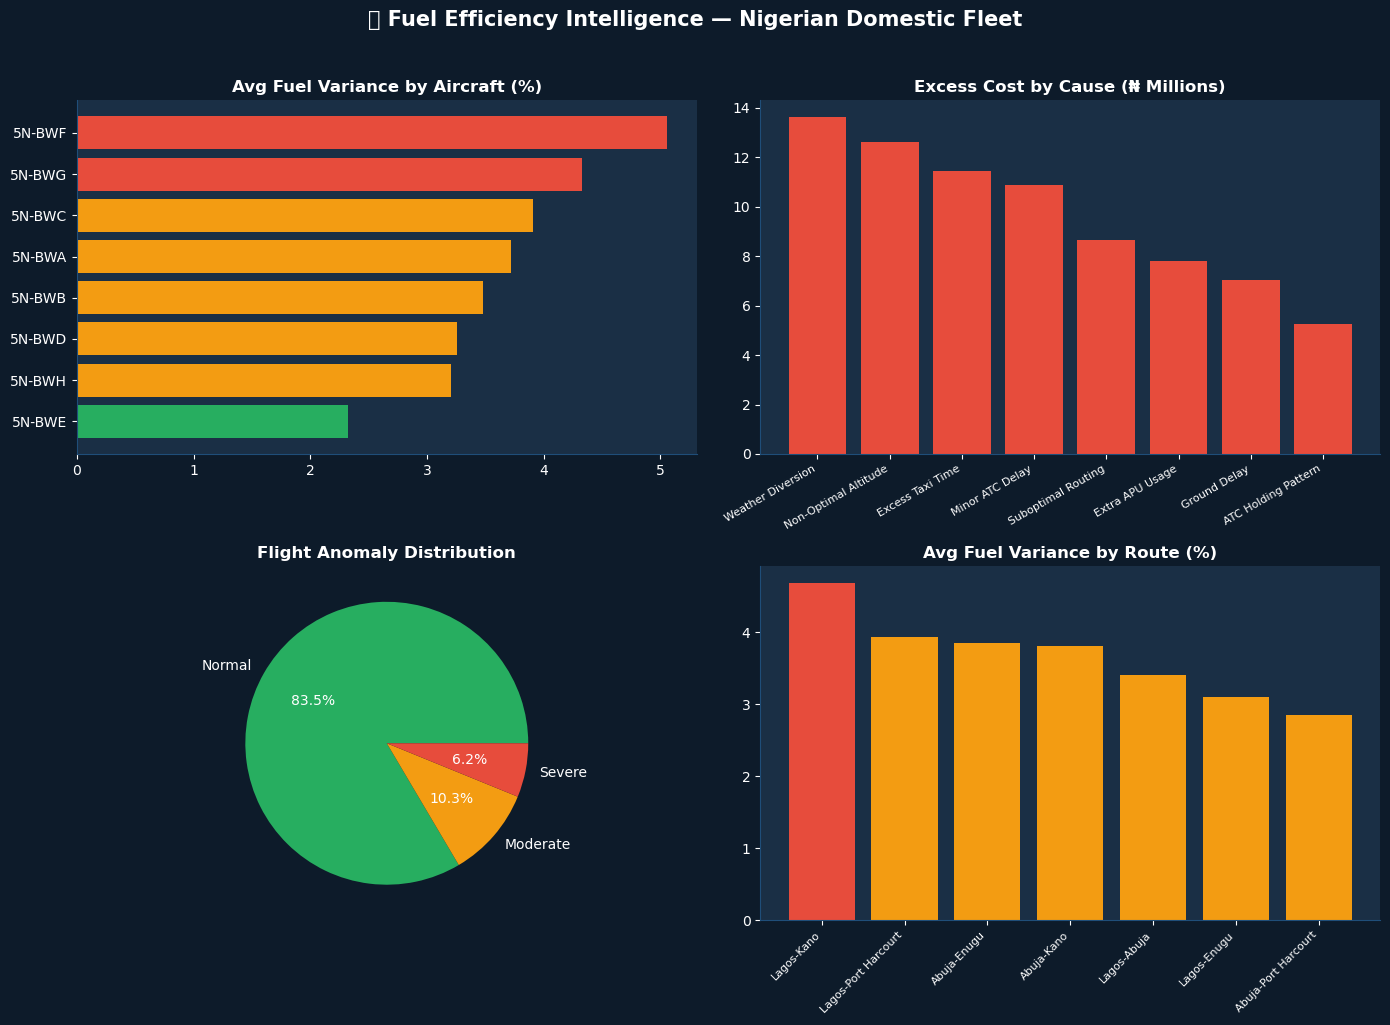

✅ Charts saved


In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0D1B2A')

colors_high = '#E74C3C'
colors_med = '#F39C12'
colors_low = '#27AE60'
bar_color = '#1F9BCF'
text_color = 'white'

# Chart 1: Aircraft variance
ax1 = axes[0,0]
ax1.set_facecolor('#1A2F45')
aircraft_plot = df.groupby('Aircraft_ID')['Fuel_Variance_Pct'].mean().sort_values()
colors1 = [colors_high if v>4 else colors_med if v>3 else colors_low for v in aircraft_plot.values]
ax1.barh(aircraft_plot.index, aircraft_plot.values, color=colors1)
ax1.set_title('Avg Fuel Variance by Aircraft (%)', color=text_color, fontweight='bold')
ax1.tick_params(colors=text_color)
for spine in ['top','right']: ax1.spines[spine].set_visible(False)
for spine in ['bottom','left']: ax1.spines[spine].set_color('#1F4E79')

# Chart 2: Cost by cause
ax2 = axes[0,1]
ax2.set_facecolor('#1A2F45')
cause_plot = df[df['Likely_Cause']!='Within Normal Range'].groupby('Likely_Cause')['Cost_Variance_NGN'].sum().sort_values(ascending=False)
ax2.bar(range(len(cause_plot)), cause_plot.values/1000000, color=colors_high)
ax2.set_xticks(range(len(cause_plot)))
ax2.set_xticklabels(cause_plot.index, rotation=30, ha='right', color=text_color, fontsize=8)
ax2.set_title('Excess Cost by Cause (₦ Millions)', color=text_color, fontweight='bold')
ax2.tick_params(colors=text_color)
for spine in ['top','right']: ax2.spines[spine].set_visible(False)
for spine in ['bottom','left']: ax2.spines[spine].set_color('#1F4E79')

# Chart 3: Anomaly severity pie
ax3 = axes[1,0]
severity_counts = df['Anomaly_Level'].value_counts()
pie_colors = [colors_low, colors_med, colors_high]
ax3.pie(severity_counts.values, labels=severity_counts.index, 
        autopct='%1.1f%%', colors=pie_colors,
        textprops={'color': text_color, 'fontsize':10})
ax3.set_title('Flight Anomaly Distribution', color=text_color, fontweight='bold')
fig.gca().set_facecolor('#0D1B2A')

# Chart 4: Route efficiency
ax4 = axes[1,1]
ax4.set_facecolor('#1A2F45')
route_plot = df.groupby('Route')['Fuel_Variance_Pct'].mean().sort_values(ascending=False)
colors4 = [colors_high if v>4 else colors_med if v>2 else colors_low for v in route_plot.values]
ax4.bar(range(len(route_plot)), route_plot.values, color=colors4)
ax4.set_xticks(range(len(route_plot)))
ax4.set_xticklabels(route_plot.index, rotation=45, ha='right', color=text_color, fontsize=8)
ax4.set_title('Avg Fuel Variance by Route (%)', color=text_color, fontweight='bold')
ax4.tick_params(colors=text_color)
for spine in ['top','right']: ax4.spines[spine].set_visible(False)
for spine in ['bottom','left']: ax4.spines[spine].set_color('#1F4E79')

fig.suptitle('⛽️ Fuel Efficiency Intelligence — Nigerian Domestic Fleet',
             color=text_color, fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('fuel_analysis_charts.png', dpi=150, bbox_inches='tight', facecolor='#0D1B2A')
plt.show()
print("✅ Charts saved")

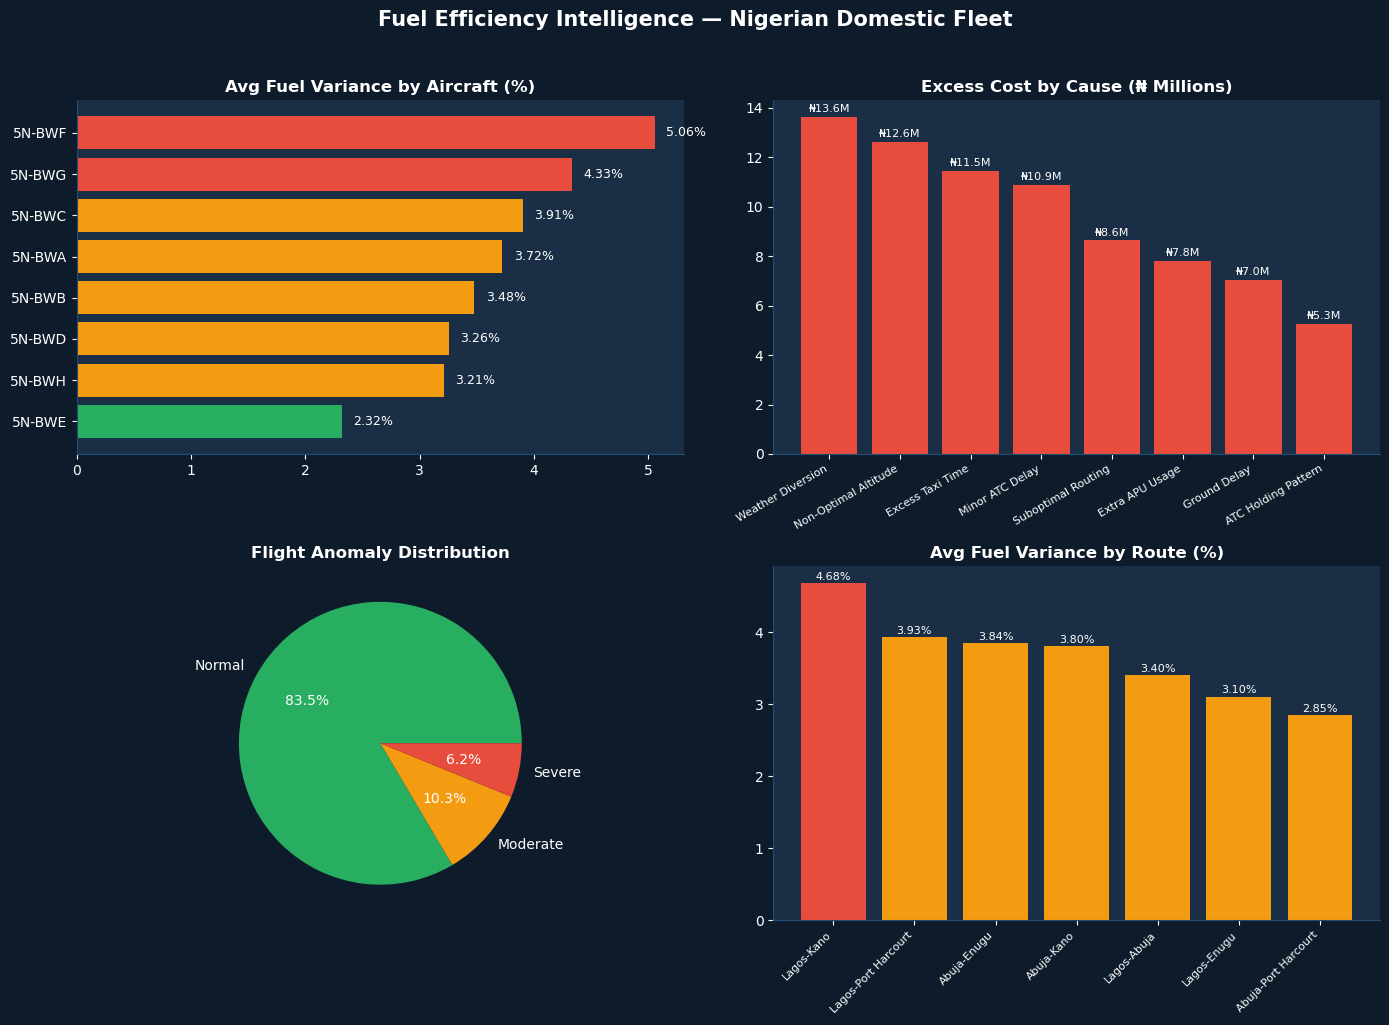

✅ Charts saved with data labels — no warnings


In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#0D1B2A')

colors_high = '#E74C3C'
colors_med = '#F39C12'
colors_low = '#27AE60'
bar_color = '#1F9BCF'
text_color = 'white'

# Chart 1: Aircraft variance WITH LABELS
ax1 = axes[0,0]
ax1.set_facecolor('#1A2F45')
aircraft_plot = df.groupby('Aircraft_ID')['Fuel_Variance_Pct'].mean().sort_values()
colors1 = [colors_high if v>4 else colors_med if v>3 else colors_low for v in aircraft_plot.values]
bars1 = ax1.barh(aircraft_plot.index, aircraft_plot.values, color=colors1)
for bar, val in zip(bars1, aircraft_plot.values):
    ax1.text(val + 0.1, bar.get_y() + bar.get_height()/2, 
              f'{val:.2f}%', va='center', color=text_color, fontsize=9)
ax1.set_title('Avg Fuel Variance by Aircraft (%)', color=text_color, fontweight='bold')
ax1.tick_params(colors=text_color)
for spine in ['top','right']: ax1.spines[spine].set_visible(False)
for spine in ['bottom','left']: ax1.spines[spine].set_color('#1F4E79')

# Chart 2: Cost by cause WITH LABELS
ax2 = axes[0,1]
ax2.set_facecolor('#1A2F45')
cause_plot = df[df['Likely_Cause']!='Within Normal Range'].groupby('Likely_Cause')['Cost_Variance_NGN'].sum().sort_values(ascending=False)
bars2 = ax2.bar(range(len(cause_plot)), cause_plot.values/1000000, color=colors_high)
for bar, val in zip(bars2, cause_plot.values/1000000):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.2,
              f'₦{val:.1f}M', ha='center', color=text_color, fontsize=8)
ax2.set_xticks(range(len(cause_plot)))
ax2.set_xticklabels(cause_plot.index, rotation=30, ha='right', color=text_color, fontsize=8)
ax2.set_title('Excess Cost by Cause (₦ Millions)', color=text_color, fontweight='bold')
ax2.tick_params(colors=text_color)
for spine in ['top','right']: ax2.spines[spine].set_visible(False)
for spine in ['bottom','left']: ax2.spines[spine].set_color('#1F4E79')

# Chart 3: Anomaly severity pie (already has labels)
ax3 = axes[1,0]
severity_counts = df['Anomaly_Level'].value_counts()
pie_colors = [colors_low, colors_med, colors_high]
ax3.pie(severity_counts.values, labels=severity_counts.index, 
        autopct='%1.1f%%', colors=pie_colors,
        textprops={'color': text_color, 'fontsize':10})
ax3.set_title('Flight Anomaly Distribution', color=text_color, fontweight='bold')

# Chart 4: Route efficiency WITH LABELS
ax4 = axes[1,1]
ax4.set_facecolor('#1A2F45')
route_plot = df.groupby('Route')['Fuel_Variance_Pct'].mean().sort_values(ascending=False)
colors4 = [colors_high if v>4 else colors_med if v>2 else colors_low for v in route_plot.values]
bars4 = ax4.bar(range(len(route_plot)), route_plot.values, color=colors4)
for bar, val in zip(bars4, route_plot.values):
    ax4.text(bar.get_x() + bar.get_width()/2, val + 0.05,
              f'{val:.2f}%', ha='center', color=text_color, fontsize=8)
ax4.set_xticks(range(len(route_plot)))
ax4.set_xticklabels(route_plot.index, rotation=45, ha='right', color=text_color, fontsize=8)
ax4.set_title('Avg Fuel Variance by Route (%)', color=text_color, fontweight='bold')
ax4.tick_params(colors=text_color)
for spine in ['top','right']: ax4.spines[spine].set_visible(False)
for spine in ['bottom','left']: ax4.spines[spine].set_color('#1F4E79')

# Main title WITHOUT emoji (fixes the warning)
fig.suptitle('Fuel Efficiency Intelligence — Nigerian Domestic Fleet',
             color=text_color, fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('fuel_analysis_charts.png', dpi=150, bbox_inches='tight', facecolor='#0D1B2A')
plt.show()
print("✅ Charts saved with data labels — no warnings")

In [5]:
import pandas as pd

df = pd.read_csv('fuel_efficiency_data.csv')

# Create a summary for the automated alert
severe_flights = df[df['Anomaly_Level'] == 'Severe'][
    ['Flight_ID', 'Flight_Date', 'Airline', 'Aircraft_ID', 
     'Route', 'Fuel_Variance_Pct', 'Cost_Variance_NGN', 'Likely_Cause']
].sort_values('Cost_Variance_NGN', ascending=False)

severe_flights.to_csv('severe_fuel_anomalies.csv', index=False)

print("✅ Severe anomaly summary ready")
print(f"Total severe flights: {len(severe_flights)}")
print(f"Total cost impact: ₦{severe_flights['Cost_Variance_NGN'].sum():,.2f}")
print(severe_flights.head(10).to_string())

✅ Severe anomaly summary ready
Total severe flights: 37
Total cost impact: ₦41,762,014.52
    Flight_ID Flight_Date           Airline Aircraft_ID                Route  Fuel_Variance_Pct  Cost_Variance_NGN          Likely_Cause
194    NG2194  2025-03-15         Air Peace      5N-BWF           Lagos-Kano              32.50         2606293.43      Excess Taxi Time
473    NG2473  2025-04-26  Overland Airways      5N-BWC           Lagos-Kano              33.58         2580524.97     Weather Diversion
384    NG2384  2025-05-25    United Nigeria      5N-BWB           Lagos-Kano              29.30         2251435.59     Weather Diversion
555    NG2555  2025-04-16         Air Peace      5N-BWG           Lagos-Kano              25.47         2042209.12      Excess Taxi Time
486    NG2486  2025-03-18    United Nigeria      5N-BWH  Abuja-Port Harcourt              31.87         1633028.03      Excess Taxi Time
141    NG2141  2025-03-12          Dana Air      5N-BWG          Lagos-Enugu            